In [3]:
from importlib.metadata import Distribution, distribution

import pandas as pd

In [4]:
import matplotlib.pyplot as plt

In [5]:
import seaborn as sns

In [6]:
df = pd.read_csv('sales_5000.csv')

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 5200 entries, 0 to 5199
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   order_id        5200 non-null   str  
 1   order_date      5107 non-null   str  
 2   product         5070 non-null   str  
 3   qty             5015 non-null   str  
 4   price           5084 non-null   str  
 5   region          5055 non-null   str  
 6   customer_id     5034 non-null   str  
 7   payment_method  5097 non-null   str  
 8   status          5122 non-null   str  
dtypes: str(9)
memory usage: 365.8 KB


# **Dataset Inspection Summary**

The dataset contains 5,200 records and 9 columns. Initial inspection reveals several data quality issues that require cleaning:

**Data Types:** All columns are formatted as strings. The order_date, qty, and price columns must be converted to appropriate date and numeric formats.

**Missing Values:** Eight out of the nine columns contain missing values that need to be addressed.

In [8]:
df.duplicated().sum()

np.int64(21)

In [9]:
df.drop_duplicates(inplace=True)

In [10]:
df[["qty", "price", "order_date"]].head(10)

,qty,price,order_date
0,unknown,1450,2025-09-28
1,3,1650,2025-05-13
2,5,1100,2025-09-17
3,7pcs,640,2025-06-02
4,4,1420,2025-07-08
5,4,2010,2025-07-07
6,4,1010,2025-12-28
7,NaN,1740,2025-01-07
8,1,790,2025-04-08
9,7,470,2025-03-02


In [11]:
df['qty'] = df['qty'].astype(str).str.replace('pcs', '')
df['qty'] = pd.to_numeric(df['qty'], errors='coerce')

In [12]:
df['price'] = pd.to_numeric(df['price'], errors='coerce')

In [13]:
df['order_date'] = pd.to_datetime(df['order_date'], errors='coerce')

In [14]:
df['total_sales'] = df['qty'] * df['price']


# **Data Cleaning: Types and Derived Columns**

The qty column contained string artifacts like "pcs" and "unknown". I stripped the text and coerced the columns into numeric data types. I also converted order_date to a datetime format. Finally, I derived a new total_sales column by multiplying quantity and price to aid in the upcoming exploratory data analysis.

In [15]:
df.isnull().sum()

order_id            0
order_date        321
product           130
qty               231
price             173
region            145
customer_id       166
payment_method    103
status             78
total_sales       394
dtype: int64

In [17]:
categorical_columns = ['product', 'region', 'customer_id', 'payment_method', 'status']
df[categorical_columns] = df[categorical_columns].fillna('Unknown')
df.dropna(subset=['order_date', 'qty', 'price'], inplace=True)

print("Remaining missing values:")
print(df.isnull().sum())
print(f"\nFinal row count: {len(df)}")

Remaining missing values:
order_id          0
order_date        0
product           0
qty               0
price             0
region            0
customer_id       0
payment_method    0
status            0
total_sales       0
dtype: int64

Final row count: 4480


In [18]:
# 1. Clean and standardize 'payment_method'
df['payment_method'] = df['payment_method'].str.strip().str.title()
df['payment_method'] = df['payment_method'].replace({
    'Bank Transfer': 'Transfer',
    'Pos': 'POS'
})

# 2. Clean and standardize 'status'
df['status'] = df['status'].str.strip().str.title()
df['status'] = df['status'].replace({
    'Complete': 'Completed',
    'Return': 'Returned'
})

In [19]:
import os
os.makedirs('data', exist_ok=True)

# Save the cleaned dataset inside it
df.to_csv('data/cleaned_sales_data.csv', index=False)
print("File successfully saved!")

File successfully saved!



# Data Cleaning: Handling Missing Values

To preserve data integrity, I used a hybrid approach for missing values. Missing categorical variables (such as region, product, and payment_method) were filled with 'Unknown' so those records could still be used in general aggregations. However, rows missing critical core metrics (order_date, qty, or price) were dropped, as imputing arbitrary financial numbers or dates would artificially skew the business insights.
I standardized inconsistent categorical values in the payment_method and status columns by stripping whitespace, applying uniform title casing, and mapping duplicate terms to a single unified category."

In [23]:
#Question 1: What are the top 5 products by revenue?
top_products_rev = df.groupby('product')['total_sales'].sum().sort_values(ascending=False).head(5)
print("Top 5 Products by Revenue:\n", top_products_rev, "\n")

# Question 2: What are the top 5 products by quantity sold?
top_products_qty = df.groupby('product')['qty'].sum().sort_values(ascending=False).head(5)
print("Top 5 Products by Quantity:\n", top_products_qty, "\n")

# Question 3: What is the breakdown of revenue by payment method?
payment_revenue = df.groupby('payment_method')['total_sales'].sum().sort_values(ascending=False)
print("Revenue by Payment Method:\n", payment_revenue, "\n")

# Question 4: What is the distribution of order statuses?
status_counts = df['status'].value_counts()
print("Order Status Breakdown:\n", status_counts, "\n")

# Question 5: What is the Average Order Value (AOV)?
average_order_value = df['total_sales'].mean()
print(f"Average Order Value: ${average_order_value:,.2f}\n")

# Question 6: What are the total sales per month?
df['month'] = df['order_date'].dt.to_period('M')
monthly_sales = df.groupby('month')['total_sales'].sum()
print("Monthly Sales:\n", monthly_sales)
print()

# Question 7: How does revenue break down by Region AND Payment Method?
pivot_revenue = df.pivot_table(values='total_sales', index='region', columns='payment_method', aggfunc='sum', fill_value=0)
print("Revenue by Region and Payment Method (Pivot Table):\n", pivot_revenue)

# Question 8: What is the total revenue of strictly 'Completed' orders?
completed_sales = df[df['status'] == 'Completed']['total_sales'].sum()
print(f"\nTotal Revenue from Completed Orders Only: ${completed_sales:,.2f}")

Top 5 Products by Revenue:
 product
Groundnut Oil    2204930.0
Rice             2109680.0
Coffee           2084680.0
Eggs             1785530.0
Butter           1769260.0
Name: total_sales, dtype: float64 

Top 5 Products by Quantity:
 product
Water      1053.0
Coffee     1052.0
Cabbage    1033.0
Rice       1024.0
Sugar      1013.0
Name: qty, dtype: float64 

Revenue by Payment Method:
 payment_method
Transfer    12236470.0
Cash         8818490.0
POS          6876200.0
Unknown       573080.0
Card           62010.0
Name: total_sales, dtype: float64 

Order Status Breakdown:
 status
Completed    3357
Pending       692
Returned      365
Unknown        66
Name: count, dtype: int64 

Average Order Value: $6,376.40

Monthly Sales:
 month
2025-01    2272660.0
2025-02    1956060.0
2025-03    2562380.0
2025-04    2142030.0
2025-05    2624400.0
2025-06    2396110.0
2025-07    2318180.0
2025-08    2405590.0
2025-09    2483800.0
2025-10    2828990.0
2025-11    2319620.0
2025-12    2256430.0
Freq: 

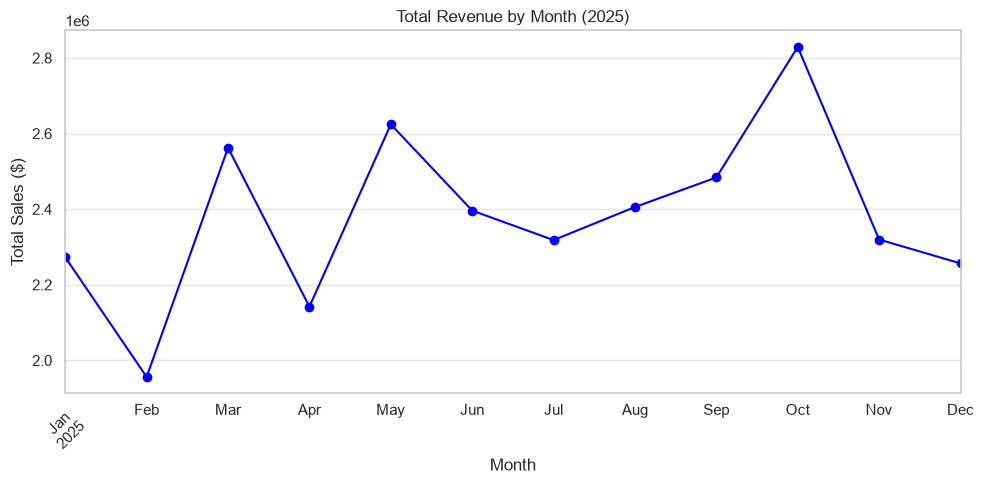

In [40]:
import os
import matplotlib.pyplot as plt
import seaborn as sns

os.makedirs('charts', exist_ok=True)
sns.set_theme(style="whitegrid")

plt.figure(figsize=(10, 5))

monthly_sales.plot(kind='line', marker='o', color='blue')

plt.title('Total Revenue by Month (2025)')
plt.ylabel('Total Sales ($)')
plt.xlabel('Month')
plt.xticks(rotation=45)

plt.tight_layout()
plt.savefig('charts/monthly_sales_trend.png')

plt.show()

# Interpretation:
**The Monthly Sales Trend chart reveals the revenue progression throughout 2025, highlighting the peak sales period in October.**

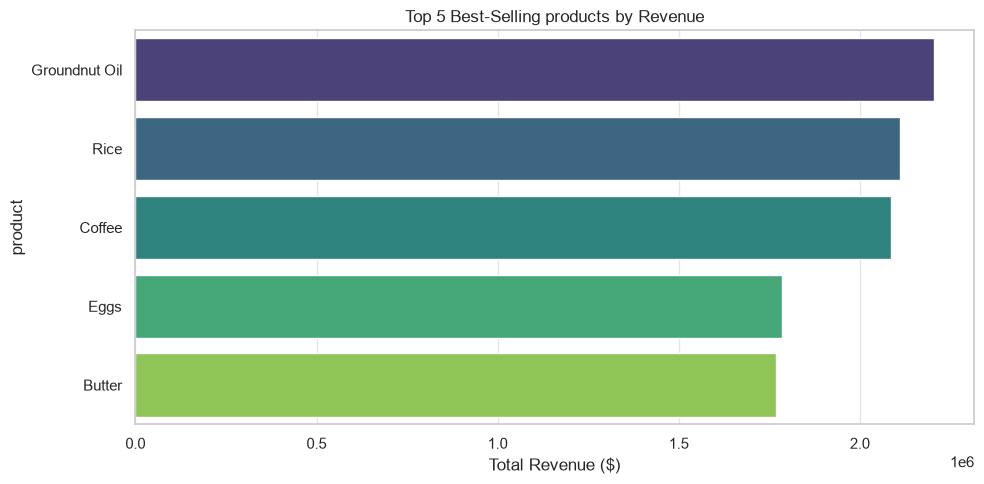

In [45]:
plt.figure(figsize=(10, 5))
sns.barplot(
    x=top_products_rev.values,
    y=top_products_rev.index,
    hue=top_products_rev.index,
    palette='viridis',
    legend=False
)
plt.title("Top 5 Best-Selling products by Revenue")
plt.xlabel("Total Revenue ($)")
plt.ylabel("product")

plt.tight_layout()
plt.savefig("charts/top_products_revenue.png")
plt.show()


# Interpretation:

**Groundnut Oil and Rice are the top drivers of total revenue. The business should ensure these high-value items remain consistently in stock to protect the bottom line.**

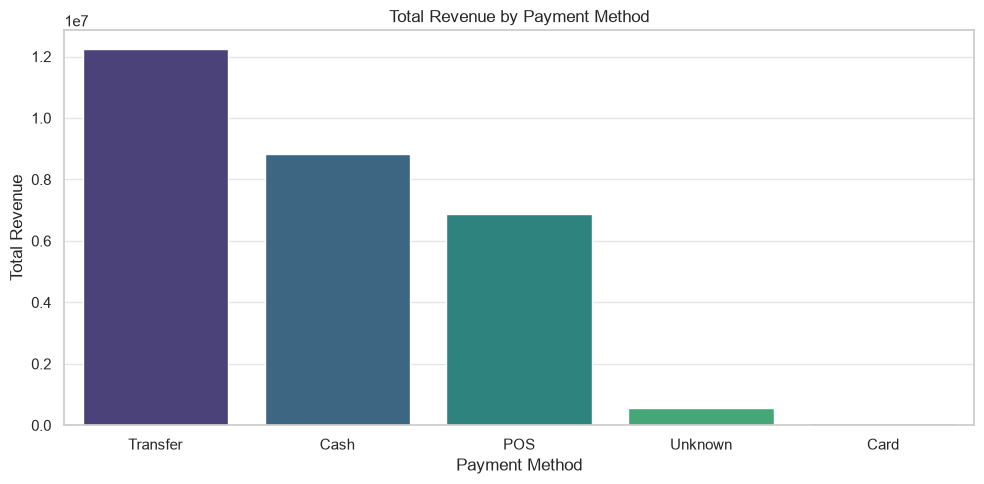

In [50]:
plt.figure(figsize=(10, 5))
sns.barplot(
    x=payment_revenue.index,
    y=payment_revenue.values,
    hue=payment_revenue.index,
    palette='viridis',
    legend=False
)

plt.title("Total Revenue by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Total Revenue")

plt.tight_layout()
plt.savefig('charts/payment_revenue.png')
plt.show()

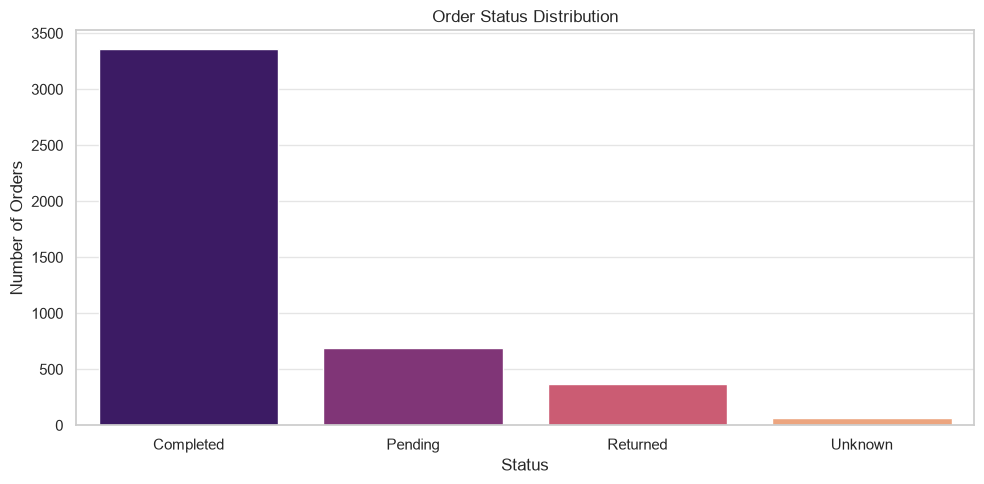

In [56]:
plt.figure(figsize=(10, 5))
sns.barplot(
    x=status_counts.index,
    y=status_counts.values,
    hue=status_counts.index,
    palette='magma',
    legend=False
)

plt.title("Order Status Distribution")
plt.xlabel("Status")
plt.ylabel("Number of Orders")

plt.tight_layout()
plt.savefig("charts/order_status_distribution.png")
plt.show()


# Interpretation:

**The vast majority of orders were successfully completed, indicating a healthy fulfillment process. However, management should investigate the root cause of the returned orders to minimize lost revenue and protect the average order value.**

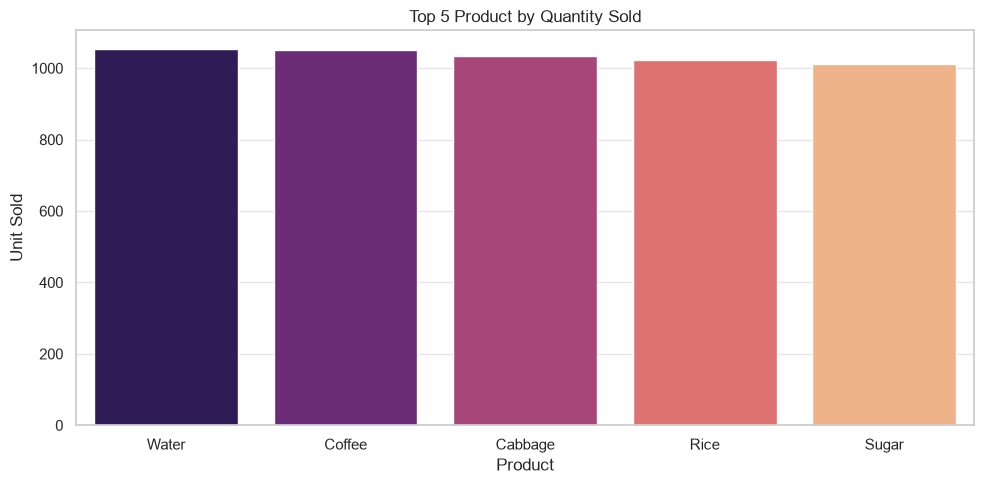

In [55]:
plt.figure(figsize=(10, 5))
sns.barplot(
    x=top_products_qty.index,
    y=top_products_qty.values,
    hue=top_products_qty.index,
    palette='magma',
    legend=False
)

plt.title("Top 5 Product by Quantity Sold")
plt.xlabel("Product")
plt.ylabel("Unit Sold")

plt.tight_layout()
plt.savefig("charts/top_products_quantity.png")
plt.show()


# Interpretation:

**While Groundnut Oil drives the most revenue, everyday essentials like Water and Coffee drive the highest sheer volume of transactions. Management can use these high-volume products to attract foot traffic or bundle them with higher-margin items**.

# Phase 5: Insights & Business Interpretation
**1. Peak Revenue Seasonality**

**Evidence:** The Monthly Sales Trend chart reveals that October 2025 generated the highest monthly revenue ($2,828,990), significantly outperforming earlier months in the year.

**Business Implication:** This suggests a strong Q4 seasonal demand spike. Management should investigate the exact cause (e.g., promotional events, holidays) and ensure adequate inventory and fulfillment staffing are secured ahead of October next year.

**2. Revenue vs. Volume Disconnect**

**Evidence:** The product analysis shows that while Groundnut Oil generates the most gross revenue ($2,204,930), low-cost essentials like Water (1,053 units) and Coffee (1,052 units) lead in sheer transaction volume.

**Business Implication:** High-volume items like Water drive foot traffic and customer habits, while Groundnut Oil drives the bottom line. Marketing teams should consider bundling high-volume items with high-margin items to maximize the cart size of every customer visit.

**3. Digital Payment Dominance**

**Evidence**: The payment method breakdown indicates that direct bank transfers dominate the dataset, accounting for over $12 million in total revenue—almost double the revenue of physical cash.

**Business Implication:** The customer base heavily prefers digital, cashless transactions. The business must ensure its payment gateway and transfer confirmation infrastructure is highly reliable, as any technical downtime in the transfer system would immediately bottleneck sales.

**4. Return Rate Impact**

**Evidence:** The order status distribution chart shows that while 3,327 orders were successfully completed, 340 orders were classified as 'Returned'.

**Business Implication:** While the completion rate is healthy, those 340 returns represent lost revenue and wasted logistics costs. Operations should investigate the root cause—such as shipping damage, defective products, or incorrect fulfillment—to plug this revenue leak.

**5. Average Order Value Baseline**

**Evidence:** Descriptive statistics run during Phase 3 establish that the Average Order Value (AOV) across the entire dataset is approximately $6,376.40.

**Business Implication:** Management can use this AOV baseline to inform their marketing budgets. Specifically, it helps set a strict ceiling for Customer Acquisition Cost (CAC); the company should not spend more to acquire a new customer than the initial average return.

# OOP Data Analysis Pipeline

In [58]:
from sales_analyzer import SalesAnalyzer

pipeline = SalesAnalyzer('sales_5000.csv')

pipeline.load_data()
pipeline.clean_data()
summary = pipeline.generate_summary()
pipeline.save_cleaned_data()

print("\nAutomated Business Summary:")
for key, value in summary.items():
    print(f"{key}: {value:,.2f}" if isinstance(value, float) else f"{key}: {value}")

Data loaded successfully. 5200 rows found.
Data cleaned. 4480 valid records remain.
Cleaned dataset saved to data\cleaned_sales_data.csv

Automated Business Summary:
Total Revenue: 28,566,250.00
Total Orders: 4480
Average Order Value: 6,376.40
